# Model Training

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
from sklearn.metrics import precision_recall_curve, auc, average_precision_score, precision_recall_curve
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

FEATURES = ['commits_count','code_churn_avg','contributors_count','contributors_experience','hunks_count',
            'issue_tracker_issues','cbo','wmc','dit','rfc','lcom','max_nested_blocks','total_refactorings',
            'ncloc_cloc','duplicated_lines_cpd_density','comment_lines_cloc_density','total_variables',
            'total_methods','Max-Ruler']

# Importing the dataset
dataset_java = pd.read_csv('dataset_final.csv', sep=',') # usecols = FEATURES

## Split dataset into training/validation and testing sets

In [3]:
# create X and Y
X = dataset_java.iloc[:, dataset_java.columns != 'Max-Ruler']
Y = dataset_java.iloc[:, dataset_java.columns == 'Max-Ruler']

# Create training and testing datasets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=0)

## Hyper-parameter tuning

In [ ]:
# create f2 scorer
f2_scorer = metrics.make_scorer(metrics.fbeta_score, beta=2)

# Logistic Regression
# model = LogisticRegression(random_state=0)
# parameters = {'model__penalty': ['l1', 'l2', 'elasticnet', 'none']}

# Linear Discriminant Analysis
# model = LinearDiscriminantAnalysis()
# parameters = {'model__solver': ['svd', 'lsqr', 'eigen']}

# Decision Tree
# model = DecisionTreeClassifier(random_state=0)   
# parameters = {'model__criterion': ['gini', 'entropy'], 'model__max_depth': [None, 2, 5, 10]}

# K-NN
# model = KNeighborsClassifier()
# parameters = {'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}

# SVM
# model = SVC(random_state=0)  
# parameters = {'model__kernel': ['linear', 'rbf'], 'model__C': [0.01, 0.1, 1, 10, 100, 1000]}

# Random Forest
# model = RandomForestClassifier(random_state=0)
# parameters = {'model__n_estimators': [5, 10, 50, 100, 500, 1000], 'model__max_depth': [None, 2, 5, 10], 'model__criterion': ['gini', 'entropy']]}

# XGBoost
# model = XGBClassifier(random_state=0)
# parameters = {'model__n_estimators': [5, 10, 50, 100, 500, 1000]}

# create pipeline
scale = MinMaxScaler()
over = SMOTE(random_state=0, sampling_strategy=1)
pipeline = Pipeline(steps=[('scale', scale), ('over', over), ('model', model)])

# perform grid search
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=1, random_state=0)
grid_search = GridSearchCV(estimator=pipeline, param_grid=parameters, scoring=f2_scorer, cv=10, verbose = 5)
grid_search = grid_search.fit(X_train, Y_train)
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_
print('Best f2 score:', grid_search.best_score_)
print('Best parameters:', grid_search.best_params_)

## Evaluate a set of models using training, cross-validation and test 

### Perform Repeated Stratified K-Fold experiments

In [4]:
# create f2 scorer
f2_scorer = metrics.make_scorer(metrics.fbeta_score, beta=2)

# create class_inspection scorer
def my_class_inspection(Y_test, y_pred):
    cm = metrics.confusion_matrix(Y_test, y_pred)
    TN = cm[0][0]
    FN = cm[1][0]
    TP = cm[1][1]
    FP = cm[0][1]
    class_inspection = (TP + FP)/(TN + FN + TP + FP)
    return class_inspection
class_inspection_scorer = metrics.make_scorer(my_class_inspection)

# create class_inspection_reduction scorer
def my_class_inspection_reduction(Y_test, y_pred):
    cm = metrics.confusion_matrix(Y_test, y_pred)
    TN = cm[0][0]
    FN = cm[1][0]
    TP = cm[1][1]
    FP = cm[0][1]
    class_inspection = (TP + FP)/(TN + FN + TP + FP)
    recall = metrics.recall_score(Y_test, y_pred, average='binary')
    class_inspection_reduction = (recall - class_inspection)/recall
    return class_inspection_reduction
class_inspection_reduction_scorer = metrics.make_scorer(my_class_inspection_reduction)

# get a list of models to evaluate
def get_models():
    models = dict()
    
    scale = MinMaxScaler()
    over = SMOTE(random_state=0, sampling_strategy=1)
    steps = []
    
    # Logistic Regression
    model = LogisticRegression(penalty='none', random_state=0)
    models['lr'] = Pipeline(steps=[('scale', scale), ('over', over), ('model', model)])
    # Naive Bayes
    model = GaussianNB()
    models['gnb'] = Pipeline(steps=[('scale', scale), ('over', over), ('model', model)])
    # Decision Tree
    model = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=0)
    models['cart'] = Pipeline(steps=[('scale', scale), ('over', over), ('model', model)])
    # K-NN
    model = KNeighborsClassifier(n_neighbors=8)    
    models['knn'] = Pipeline(steps=[('scale', scale), ('over', over), ('model', model)])
    # SVM
    model = SVC(kernel='rbf', C=1, random_state=0)    
    models['svm'] = Pipeline(steps=[('scale', scale), ('over', over), ('model', model)])
    # Random Forest
    model = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=14, n_jobs=-1, random_state=0)
    models['rf'] = Pipeline(steps=[('scale', scale), ('over', over), ('model', model)])
    # XGBoost
    model = XGBClassifier(n_estimators=50, random_state=0)    
    models['xgb'] = Pipeline(steps=[('scale', scale), ('over', over), ('model', model)])
    
    return models

# evaluate a give model using cross-validation
def evaluate_model(model, X, Y):
    scoring = {'accuracy':'accuracy',
               'precision':'precision',
               'recall':'recall',
               'f1':'f1',
               'f2':f2_scorer,
               'class_inspection':class_inspection_scorer,
               'class_inspection_reduction':class_inspection_reduction_scorer}
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=0)
    scores = cross_validate(model, X, Y, scoring=scoring, cv=cv, n_jobs=-1)
    return scores

# get the models to evaluate
models = get_models()
# evaluate the models and store results
results = dict()
results_df = pd.DataFrame()
for name, model in models.items():
    scores = evaluate_model(model, X_train, Y_train)
    results[name] = scores
    results_df = results_df.append(
    {'Model':name, 
       'Accuracy':'%.3f (%.3f)' % (scores['test_accuracy'].mean(), scores['test_accuracy'].std()),
       'Precision':'%.3f (%.3f)' % (scores['test_precision'].mean(), scores['test_precision'].std()), 
       'Recall':'%.3f (%.3f)' % (scores['test_recall'].mean(), scores['test_recall'].std()),
       'F1-score':'%.3f (%.3f)' % (scores['test_f1'].mean(), scores['test_f1'].std()),
       'F2-score':'%.3f (%.3f)' % (scores['test_f2'].mean(), scores['test_f2'].std()),
       'Class Inspection':'%.3f (%.3f)' % (scores['test_class_inspection'].mean(), scores['test_class_inspection'].std()),
       'Class Inspection Reduction':'%.3f (%.3f)' % (scores['test_class_inspection_reduction'].mean(), scores['test_class_inspection_reduction'].std()),
       # 'fit time': '%.3f' % (scores['fit_time'].mean()),
       # 'score time': '%.3f' % (scores['score_time'].mean()),
    }, ignore_index=True)
# print results
results_df.set_index('Model', inplace=True)
results_df

,Accuracy,Class Inspection,Class Inspection Reduction,F1-score,F2-score,Precision,Recall
Model,,,,,,,
lr,0.923 (0.006),0.133 (0.007),0.855 (0.007),0.613 (0.021),0.764 (0.020),0.462 (0.022),0.914 (0.026)
gnb,0.921 (0.005),0.118 (0.007),0.850 (0.007),0.572 (0.022),0.684 (0.027),0.449 (0.021),0.788 (0.038)
cart,0.938 (0.005),0.090 (0.007),0.872 (0.007),0.604 (0.033),0.663 (0.042),0.527 (0.031),0.709 (0.054)
knn,0.922 (0.006),0.127 (0.007),0.853 (0.008),0.596 (0.023),0.731 (0.024),0.456 (0.023),0.861 (0.031)
svm,0.916 (0.006),0.141 (0.007),0.848 (0.007),0.597 (0.020),0.758 (0.019),0.441 (0.020),0.925 (0.027)
rf,0.949 (0.003),0.094 (0.005),0.886 (0.004),0.684 (0.019),0.760 (0.025),0.586 (0.022),0.822 (0.035)
xgb,0.921 (0.005),0.134 (0.006),0.853 (0.005),0.609 (0.018),0.761 (0.021),0.458 (0.018),0.914 (0.031)


### Plot Cross-Validated Precision - Recall curves

In [ ]:
def draw_cv_pr_curve(classifiers, cv, X, Y, title):
    # initialize figure
    plt.figure(figsize=(10, 10))
    
    # for each classifier
    for name, classifier in classifiers.items():
        y_real = []
        y_proba = []
        i = 0
        # for each fold
        for train, test in cv.split(X, Y):
            X_train = X.iloc[train]
            Y_train = Y.iloc[train]
            X_test = X.iloc[test]
            Y_test = Y.iloc[test]

            # Normalise using MinMax
            sc = MinMaxScaler()
            X_train = sc.fit_transform(X_train)
            X_test = sc.transform(X_test)
            
            # Resampling using SMOTE
            sm = SMOTE(random_state=0, sampling_strategy=1)
            X_train, Y_train = sm.fit_sample(X_train, Y_train)
            
            # Compute probabilities
            probas_ = classifier.fit(X_train, Y_train).predict_proba(X_test)
            # Compute ROC curve and area under the curve
            # precision, recall, _ = precision_recall_curve(Y_test, probas_[:, 1])
            # Plotting each individual PR Curve
            # plt.plot(recall, precision, lw=1, alpha=0.3, label='PR fold %d (AUC = %0.2f)' % (i, average_precision_score(Y_test, probas_[:, 1])))

            y_real.append(Y_test)
            y_proba.append(probas_[:, 1])
            i += 1

        y_real = np.concatenate(y_real)
        y_proba = np.concatenate(y_proba)

        # Compute area under the curve
        precision, recall, _ = precision_recall_curve(y_real, y_proba)
        # Plot classifier's PR curve and compute Average Precision score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
        plt.plot(recall, precision, label=r'%s (AUC = %0.2f)' % (name, average_precision_score(y_real, y_proba)), lw=2, alpha=.8)

    # Plot no-skill classifier
    no_skill = len(Y_test.loc[Y_test['Max-Ruler']==1]) / len(Y_test)
    plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')

    # Show plot
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Recall (high-TD class)', fontsize=18)
    plt.ylabel('Precision (high-TD class)', fontsize=18)
    plt.title(title, fontsize=20)
    plt.legend(loc='best', fontsize=10)
    plt.show()
    
# create X and Y
X = dataset_java.iloc[:, dataset_java.columns != 'Max-Ruler']
Y = dataset_java.iloc[:, dataset_java.columns == 'Max-Ruler']

# Create training and testing datasets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=0)

# Create classifiers
classifiers = dict()
# Logistic Regression
model = LogisticRegression(random_state=0)
classifiers['Logistic Regression'] = model
# # Linear Discriminant Analysis
# model = LinearDiscriminantAnalysis(solver='svd')
# classifiers['LDA'] = model
# Naive Bayes
model = GaussianNB()
classifiers['Naive Bayes'] = model
# Decision Tree
model = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=0)
classifiers['Decision Tree'] = model
# K-NN
model = KNeighborsClassifier(n_neighbors=8)
classifiers['K-NN'] = model
# SVM
model = SVC(kernel='rbf', probability=True, random_state=0)
classifiers['SVM'] = model
# Random Forest
model = RandomForestClassifier(n_estimators=100, criterion='gini', n_jobs=-1, random_state=0)
classifiers['Random Forest'] = model
# XGBoost
model = XGBClassifier(n_estimators=50, random_state=0)
classifiers['XGBoost'] = model

# Define cross-validation strategy
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=0)

# Call draw_cv_pr_curve()
draw_cv_pr_curve(classifiers, cv, X_train, Y_train, title='Cross-Validated Precision-Recall Curves')

### Perform Testing experiments

In [5]:
# get a list of models to test
def get_final_models():
    models = dict()
    
    # ================= #
    # Linear Algorithms #
    # ================= #
    # Logistic Regression
    model = LogisticRegression(penalty='none', random_state=0)
    models['lr'] = model
    # Naive Bayes
    model = GaussianNB()
    models['gnb'] = model
    # ==================== #
    # Nonlinear Algorithms #
    # ==================== #    
    # Decision Tree
    model = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=0)
    models['cart'] = model
    # K-NN
    model = KNeighborsClassifier(n_neighbors=8)    
    models['knn'] = model
    # SVM
    model = SVC(kernel='rbf', C=1, random_state=0)    
    models['svm'] = model
    # =================== #
    # Ensemble Algorithms #
    # =================== #
    # Random Forest
    model = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=14, n_jobs=-1, random_state=0)
    models['rf'] = model
    # XGBoost
    model = XGBClassifier(n_estimators=50, random_state=0)    
    models['xgb'] = model
    
    return models

# get the final models to test
final_models = get_final_models()
# evaluate the final models and store results
final_results_df = pd.DataFrame()

# Normalise using MinMax
scaler = MinMaxScaler() # or StandardScaler
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Resampling using SMOTE
sm = SMOTE(random_state=0, sampling_strategy=1)
X_train, Y_train = sm.fit_resample(X_train, Y_train)
    
for name, model in final_models.items():
    # Training the model using the Train-Validation set
    model.fit(X_train, Y_train)

    # Predicting the Test set results
    y_pred = model.predict(X_test)

    # Making the Confusion Matrix
    cm = metrics.confusion_matrix(Y_test, y_pred)

    # Print model accuracy scores
    TN = cm[0][0]
    FN = cm[1][0]
    TP = cm[1][1]
    FP = cm[0][1]
    accuracy = metrics.accuracy_score(Y_test, y_pred)
    precision = metrics.precision_score(Y_test, y_pred, average='binary')
    recall = metrics.recall_score(Y_test, y_pred, average='binary')
    f1 = metrics.f1_score(Y_test, y_pred, average='binary')
    f2 = metrics.fbeta_score(Y_test, y_pred, average='binary', beta=2)
    class_inspection = (TP + FP)/(TN + FN + TP + FP)
    class_inspection_reduction = (recall - class_inspection)/recall
    
    final_results_df = final_results_df.append(
    {'Model':name, 
       'Accuracy':'%.3f' % accuracy,
       'Precision':'%.3f' % precision, 
       'Recall':'%.3f' % recall,
       'F1-score':'%.3f' % f1,
       'F2-score':'%.3f' % f2,
       'Class Inspection':'%.3f' % class_inspection,
       'Class Inspection Reduction':'%.3f' % class_inspection_reduction,
    }, ignore_index=True)
# print results
final_results_df.set_index('Model', inplace=True)
final_results_df  

C:\Users\tsoukj\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)
C:\Users\tsoukj\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:86: FutureWarning: Function safe_indexing is deprecated; safe_indexing is deprecated in version 0.22 and will be removed in version 0.24.
  warnings.warn(msg, category=FutureWarning)


,Accuracy,Class Inspection,Class Inspection Reduction,F1-score,F2-score,Precision,Recall
Model,,,,,,,
lr,0.927,0.131,0.860,0.634,0.787,0.479,0.937
gnb,0.926,0.116,0.857,0.597,0.712,0.471,0.816
cart,0.941,0.092,0.877,0.630,0.694,0.546,0.745
knn,0.924,0.126,0.855,0.607,0.743,0.464,0.874
svm,0.919,0.142,0.852,0.614,0.781,0.452,0.954
rf,0.952,0.096,0.888,0.707,0.790,0.601,0.858
xgb,0.927,0.133,0.859,0.633,0.788,0.477,0.941


### Plot model performance box-plots for comparison

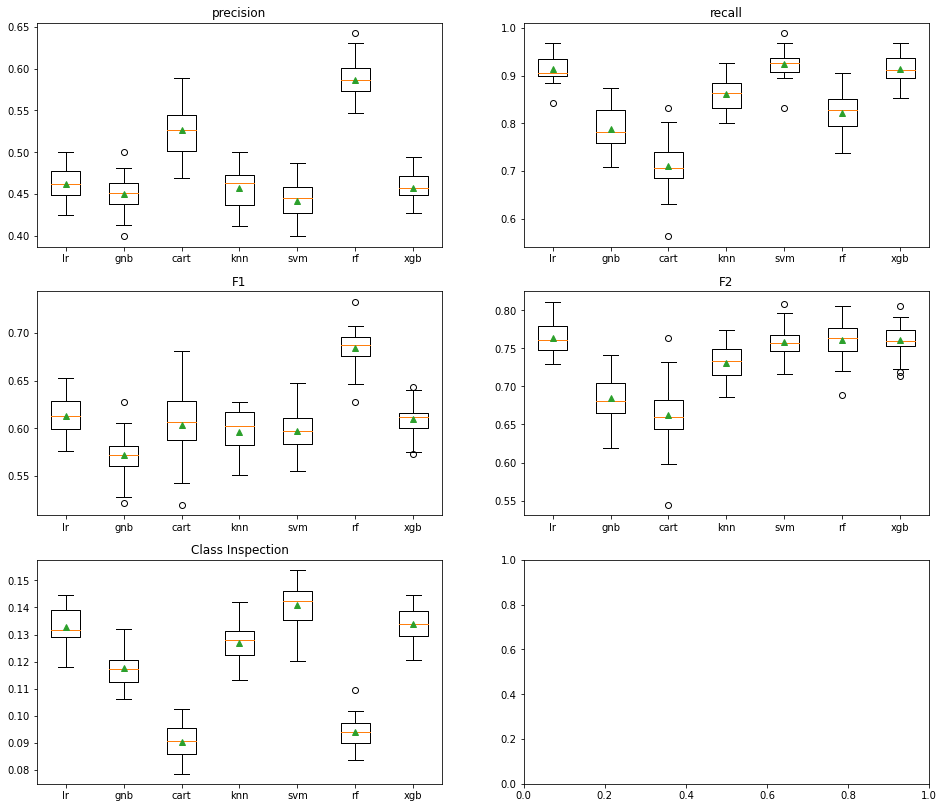

In [6]:
# plot model performance for comparison
acc = list()
pre = list()
rec = list()
f1 = list()
f2 = list()
ci = list()

for name in results:
    acc.append(results[name]['test_accuracy'].tolist())
    pre.append(results[name]['test_precision'].tolist())
    rec.append(results[name]['test_recall'].tolist())
    f1.append(results[name]['test_f1'].tolist())
    f2.append(results[name]['test_f2'].tolist())
    ci.append(results[name]['test_class_inspection'].tolist())

fig, axs = plt.subplots(3, 2, figsize=(16, 14))
# axs[0, 0].set_title('accuracy')
# axs[0, 0].boxplot(acc, labels=list(results.keys()), showmeans=True)
axs[0, 0].set_title('precision')
axs[0, 0].boxplot(pre, labels=list(results.keys()), showmeans=True)
axs[0, 1].set_title('recall')
axs[0, 1].boxplot(rec, labels=list(results.keys()), showmeans=True)
axs[1, 0].set_title('F1')
axs[1, 0].boxplot(f1, labels=list(results.keys()), showmeans=True)
axs[1, 1].set_title('F2')
axs[1, 1].boxplot(f2, labels=list(results.keys()), showmeans=True)
axs[2, 0].set_title('Class Inspection')
axs[2, 0].boxplot(ci, labels=list(results.keys()), showmeans=True)

plt.show()

### Calculate statistical differences between classifiers using Wilcoxon signed-rank test 

In [ ]:
from scipy.stats import wilcoxon

wilc_df = pd.DataFrame()
for model in results:
    wilc_df = wilc_df.append(pd.Series(name=model))
    for model2 in results:
        stat, p = wilcoxon(results[model]['test_f2'], results[model2]['test_f2'])
        wilc_df.at[model,model2] = p
        # print(model,' - ', model2, ': ', p)
wilc_df

## Use Pickle to export the trained model

In [ ]:
import pickle

FEATURES = ['commits_count','code_churn_avg','contributors_count','contributors_experience','hunks_count',
            'cbo','wmc','dit','rfc','lcom','max_nested_blocks','total_refactorings',
            'ncloc_cloc','duplicated_lines_cpd_density','comment_lines_cloc_density','total_variables',
            'total_methods','Max-Ruler']

# Importing the dataset
dataset_java = pd.read_csv('dataset_final.csv', sep=',', usecols = FEATURES)

#========================= Train and Test models ==============================#
# Create X and Y
X = dataset_java.iloc[:, dataset_java.columns != 'Max-Ruler']
Y = dataset_java.iloc[:, dataset_java.columns == 'Max-Ruler']

# Normalise using MinMax
scaler = MinMaxScaler() # or StandardScaler
X = scaler.fit_transform(X)

# Resampling using SMOTE
sm = SMOTE(random_state=0, sampling_strategy=1)
X, Y = sm.fit_resample(X, Y)

# Fitting Random Forest Classification to the Training set
classifier = RandomForestClassifier(random_state=0)
classifier.fit(X, Y)

In [ ]:
# save the model to disk
model_filename = 'finalized_model.sav'
scaler_filename = 'finalized_scaler.sav'
pickle.dump(classifier, open(model_filename, 'wb'))
pickle.dump(scaler, open(scaler_filename, 'wb'))